<a href="https://colab.research.google.com/github/Kragmork/pyRAT/blob/main/Metadata_Srov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Srovnání práce s metadaty - Rasterio / XArray



In [2]:
import pandas as pd
import numpy as np

import rasterio

import xarray
!pip install rioxarray
import rioxarray as rxr

import matplotlib as mpl

## Funkce
* Načítání vlastností rasteru

In [5]:

path = '/content/RGB.byte.tif'
src = rasterio.open(path)
print('Počet pásem, řádků a sloupců rasteru: ',src.read().shape)

print('CRS: ',src.crs)

print(src.bounds)

Počet pásem, řádků a sloupců rasteru:  (3, 718, 791)
CRS:  EPSG:32618
BoundingBox(left=101985.0, bottom=2611485.0, right=339315.0, top=2826915.0)


In [10]:
riox = rxr.open_rasterio(path)
riox.rio.crs


CRS.from_wkt('PROJCS["WGS 84 / UTM zone 18N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32618"]]')

* Vizualizace <br>
Kvůli odlišné struktuře rasteru je potřeba soubor nejdříve přeformátovat







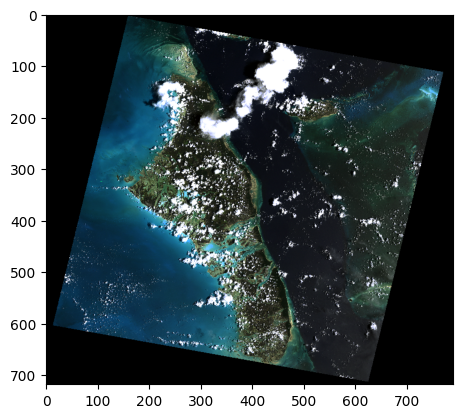

In [ ]:
from rasterio.plot import reshape_as_raster, reshape_as_image
vis = reshape_as_image(src.read())
mpl.pyplot.imshow(vis)

* Maskování

In [ ]:

msk = src.read_masks(1)
print(msk)

print(msk[300:310,300:310])

* Vizualizace masky

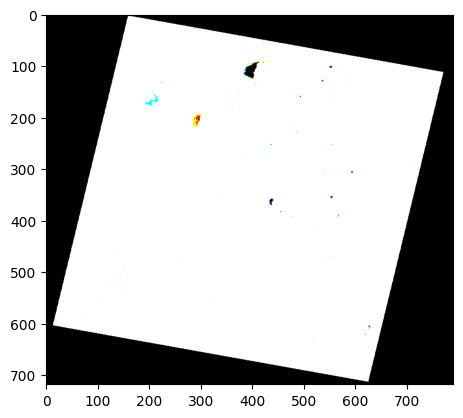

In [ ]:
msk = src.read_masks()
msk = reshape_as_image(msk)
mpl.pyplot.imshow(msk)

In [ ]:
dst = rasterio.open('/content/new_file.tif', #filepath
                    'w', #mode - writing
                    'GTiff', #driver / format
                    dtype = 'uint8',
                    width=src.width,
                    height = src.height,
                    count = src.count,
                    crs = src.crs,
                    transform = src.transform)
new_src = rasterio.open('/content/new_file.tif')
print(new_src.shape)

(718, 791)
